# LazyZarr decimation sweep — results visualisation

This notebook loads the CSV + PNG artefacts produced by
[`run_lazy_zarr_decimation_sweep.pbs`](run_lazy_zarr_decimation_sweep.pbs)
(which in turn runs
[`lazy_zarr_interpolation_decimation_sweep.py`](lazy_zarr_interpolation_decimation_sweep.py))
and turns them into a single interactive summary.

For each preset the sweep writes

| file | content |
|---|---|
| `<config>_per_spectrum.csv` | one row per held-out spectrum (parameters + RMS / mean / max-abs % residual vs the full-grid truth) |
| `<config>_by_parameter.csv` | mean / median / max RMS % aggregated against each axis value |
| `<config>_errors.png` | the figure already rendered by the sweep script |
| `summary.csv` | one row per preset with min / median / mean / p95 / max RMS % |
| `summary_comparison.png` | cross-config min/median/max bar chart |

The cells below stitch those files into:

1. The headline summary table.
2. Overlaid RMS % histograms and CDFs across configs.
3. Teff–log g heatmaps of mean and max RMS for each config.
4. RMS % vs every catalogue axis (from `<config>_by_parameter.csv`).
5. Worst-case spectra rankings.
6. Example spectra — corner vertices used for interpolation, held-out truth, and reconstruction (requires the zarr store).
7. The original sweep PNGs embedded as a sanity-check.

Set `RESULTS_DIR` below to the `--output-dir` you ran the sweep with.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

RESULTS_DIR = Path("/home/100/mj8805/scr_y89/spice/lazy_zarr_decimation_sweep").resolve()
if not RESULTS_DIR.is_dir():
    candidates = [
        Path("lazy_zarr_decimation_sweep").resolve(),
        Path("../lazy_zarr_decimation_sweep").resolve(),
        Path("../data/lazy_zarr_decimation_sweep").resolve(),
    ]
    for c in candidates:
        if c.is_dir():
            RESULTS_DIR = c
            break

assert RESULTS_DIR.is_dir(), (
    f"RESULTS_DIR={RESULTS_DIR} not found. Set it to your sweep --output-dir."
)
print("Results directory:", RESULTS_DIR)
print("Files:", sorted(p.name for p in RESULTS_DIR.iterdir()))


Results directory: /scratch/y89/mj8805/spice/lazy_zarr_decimation_sweep
Files: ['keep_3_interp_2_by_parameter.csv', 'keep_3_interp_2_errors.png', 'keep_3_interp_2_per_spectrum.csv', 'keep_4_interp_2_by_parameter.csv', 'keep_4_interp_2_errors.png', 'keep_4_interp_2_per_spectrum.csv', 'leave_out_half_by_parameter.csv', 'leave_out_half_errors.png', 'leave_out_half_per_spectrum.csv', 'summary.csv', 'summary_comparison.png']


## 1. Summary

In [2]:
summary = pd.read_csv(RESULTS_DIR / "summary.csv")

display_cols = [
    "config",
    "description",
    "n_kept_rows",
    "n_held_rows_full_mask",
    "n_held",
    "kept_teff",
    "kept_logg",
    "held_teff",
    "held_logg",
    "rms_pct_min",
    "rms_pct_median",
    "rms_pct_mean",
    "rms_pct_p95",
    "rms_pct_max",
]
display_cols = [c for c in display_cols if c in summary.columns]

with pd.option_context("display.float_format", "{:,.3f}".format):
    display(summary[display_cols])


,config,description,n_kept_rows,n_held_rows_full_mask,n_held,kept_teff,kept_logg,held_teff,held_logg,rms_pct_min,rms_pct_median,rms_pct_mean,rms_pct_p95,rms_pct_max
0,leave_out_half,"keep i ≡ 0 (mod 2), held i ≡ 1 (mod 2), held ∩...",150381,136400,136400,21,21,20,20,0.000,8.619,9.396,22.328,78.049
1,keep_4_interp_2,"keep i ≡ 0 (mod 4), held i ≡ 2 (mod 2), held ∩...",41261,102300,102300,11,11,20,20,0.000,2.135,5.742,20.285,78.049
2,keep_3_interp_2,"keep i ≡ 0 (mod 3), held i ≡ 2 (mod 2), held ∩...",66836,124124,124124,14,14,20,20,0.000,5.947,7.200,17.919,76.528


In [3]:
configs = summary["config"].tolist()

per_spec: dict[str, pd.DataFrame] = {}
by_param: dict[str, pd.DataFrame] = {}

for cfg in configs:
    per_spec[cfg] = pd.read_csv(RESULTS_DIR / f"{cfg}_per_spectrum.csv")
    by_param[cfg] = pd.read_csv(RESULTS_DIR / f"{cfg}_by_parameter.csv")

for cfg in configs:
    n = len(per_spec[cfg])
    rms = per_spec[cfg]["rms_pct"]
    print(
        f"{cfg:>20s}: N={n:>7d}  "
        f"median={rms.median():6.3f}%  "
        f"mean={rms.mean():6.3f}%  "
        f"p95={rms.quantile(0.95):6.3f}%  "
        f"max={rms.max():7.3f}%"
    )


      leave_out_half: N= 136400  median= 8.619%  mean= 9.396%  p95=22.328%  max= 78.049%
     keep_4_interp_2: N= 102300  median= 2.135%  mean= 5.742%  p95=20.285%  max= 78.049%
     keep_3_interp_2: N= 124124  median= 5.947%  mean= 7.200%  p95=17.919%  max= 76.528%


## 2. RMS distributions across configs

Two views of the same per-spectrum RMS % residual:

* **Histogram** — frequency of error magnitudes, log-scaled y to keep the long max-RMS tail visible.
* **CDF** — fraction of held-out spectra reconstructed below each error threshold. The further left a curve, the better the preset.

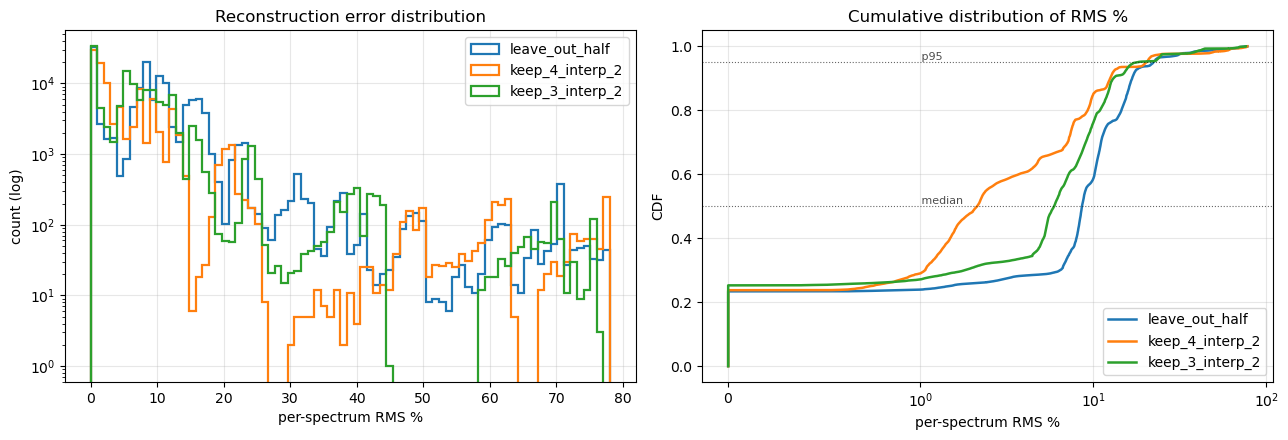

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(0, max(per_spec[c]["rms_pct"].max() for c in configs), 80)
for cfg in configs:
    rms = per_spec[cfg]["rms_pct"].to_numpy()
    axes[0].hist(rms, bins=bins, histtype="step", linewidth=1.6, label=cfg)
axes[0].set_yscale("log")
axes[0].set_xlabel("per-spectrum RMS %")
axes[0].set_ylabel("count (log)")
axes[0].set_title("Reconstruction error distribution")
axes[0].legend()
axes[0].grid(alpha=0.3)

for cfg in configs:
    rms = np.sort(per_spec[cfg]["rms_pct"].to_numpy())
    cdf = np.arange(1, len(rms) + 1) / len(rms)
    axes[1].plot(rms, cdf, label=cfg, linewidth=1.8)
axes[1].set_xlabel("per-spectrum RMS %")
axes[1].set_ylabel("CDF")
axes[1].set_xscale("symlog", linthresh=1.0)
axes[1].set_title("Cumulative distribution of RMS %")
axes[1].axhline(0.5, color="k", linestyle=":", linewidth=0.8, alpha=0.6)
axes[1].axhline(0.95, color="k", linestyle=":", linewidth=0.8, alpha=0.6)
axes[1].text(bins[1], 0.5, " median", va="bottom", fontsize=8, alpha=0.7)
axes[1].text(bins[1], 0.95, " p95", va="bottom", fontsize=8, alpha=0.7)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()


## 3. Cross-config bar chart

Replicates `summary_comparison.png` interactively, with mean and p95 added next to the min / median / max bars from the script.

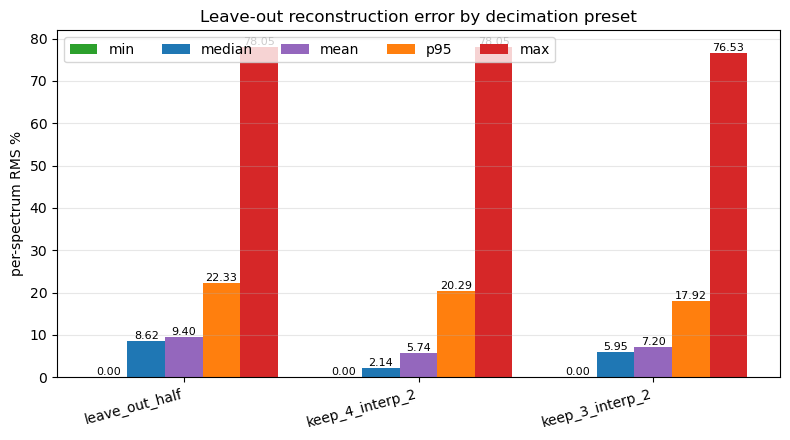

In [5]:
metrics = [
    ("rms_pct_min", "min", "C2"),
    ("rms_pct_median", "median", "C0"),
    ("rms_pct_mean", "mean", "C4"),
    ("rms_pct_p95", "p95", "C1"),
    ("rms_pct_max", "max", "C3"),
]
metrics = [m for m in metrics if m[0] in summary.columns]

x = np.arange(len(configs))
width = 0.8 / len(metrics)

fig, ax = plt.subplots(figsize=(max(7.0, 1.6 * len(configs) * len(metrics) / 3), 4.5))
for i, (col, label, color) in enumerate(metrics):
    offset = (i - (len(metrics) - 1) / 2) * width
    bars = ax.bar(x + offset, summary[col], width=width, label=label, color=color)
    for b, v in zip(bars, summary[col]):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=0,
        )

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=15, ha="right")
ax.set_ylabel("per-spectrum RMS %")
ax.set_title("Leave-out reconstruction error by decimation preset")
ax.legend(ncol=len(metrics), loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()


## 4. Teff–log g error landscape

Each **square** is one `(Teff, log g)` thermal cell that was actually **held out** in the decimation preset (RMS % aggregated over all other parameters at that cell). We plot only those cells — not a dense `imshow` over every Teff × log g pair — so you see the true held-out **checkerboard** (for `leave_out_half`) without white gaps that looked like missing data.


In [ ]:
def aggregate_held_thermal(df: pd.DataFrame, reducer) -> pd.DataFrame:
    """One row per (Teff, log g) with held-out spectra; no NaN filler cells."""
    return (
        df.groupby(["teff", "logg"], as_index=False)["rms_pct"]
        .agg(reducer)
        .rename(columns={"rms_pct": "value"})
    )


fig, axes = plt.subplots(
    len(configs), 2, figsize=(11, 3.8 * len(configs)), squeeze=False
)

for row, cfg in enumerate(configs):
    df = per_spec[cfg]
    panels = [
        (aggregate_held_thermal(df, "mean"), "mean RMS %"),
        (aggregate_held_thermal(df, "max"), "max RMS %"),
    ]
    vmax = max(float(p["value"].quantile(0.99)) for p, _ in panels)
    vmax = max(vmax, 1e-6)

    for col, (pts, subtitle) in enumerate(panels):
        ax = axes[row, col]
        sc = ax.scatter(
            pts["logg"],
            pts["teff"],
            c=pts["value"],
            s=36,
            cmap="magma",
            vmin=0,
            vmax=vmax,
            marker="s",
            linewidths=0.15,
            edgecolors="0.15",
        )
        ax.set_xlabel("log g")
        ax.set_ylabel("Teff")
        ax.set_title(f"{cfg} — {subtitle}\n({len(pts)} held-out thermal cells)")
        ax.grid(alpha=0.3)
        plt.colorbar(sc, ax=ax, fraction=0.046, label="RMS %")

fig.suptitle(
    "Held-out (Teff, log g) cells only — decimation pattern visible, no gap-filled grid",
    y=1.01,
    fontsize=11,
)
fig.tight_layout()


## 5. RMS vs each catalogue axis

`*_by_parameter.csv` already aggregates RMS % against every axis value. Per parameter we overlay every preset so the relative ordering is obvious. Constant axes (zero spread) are collapsed into a single dot.

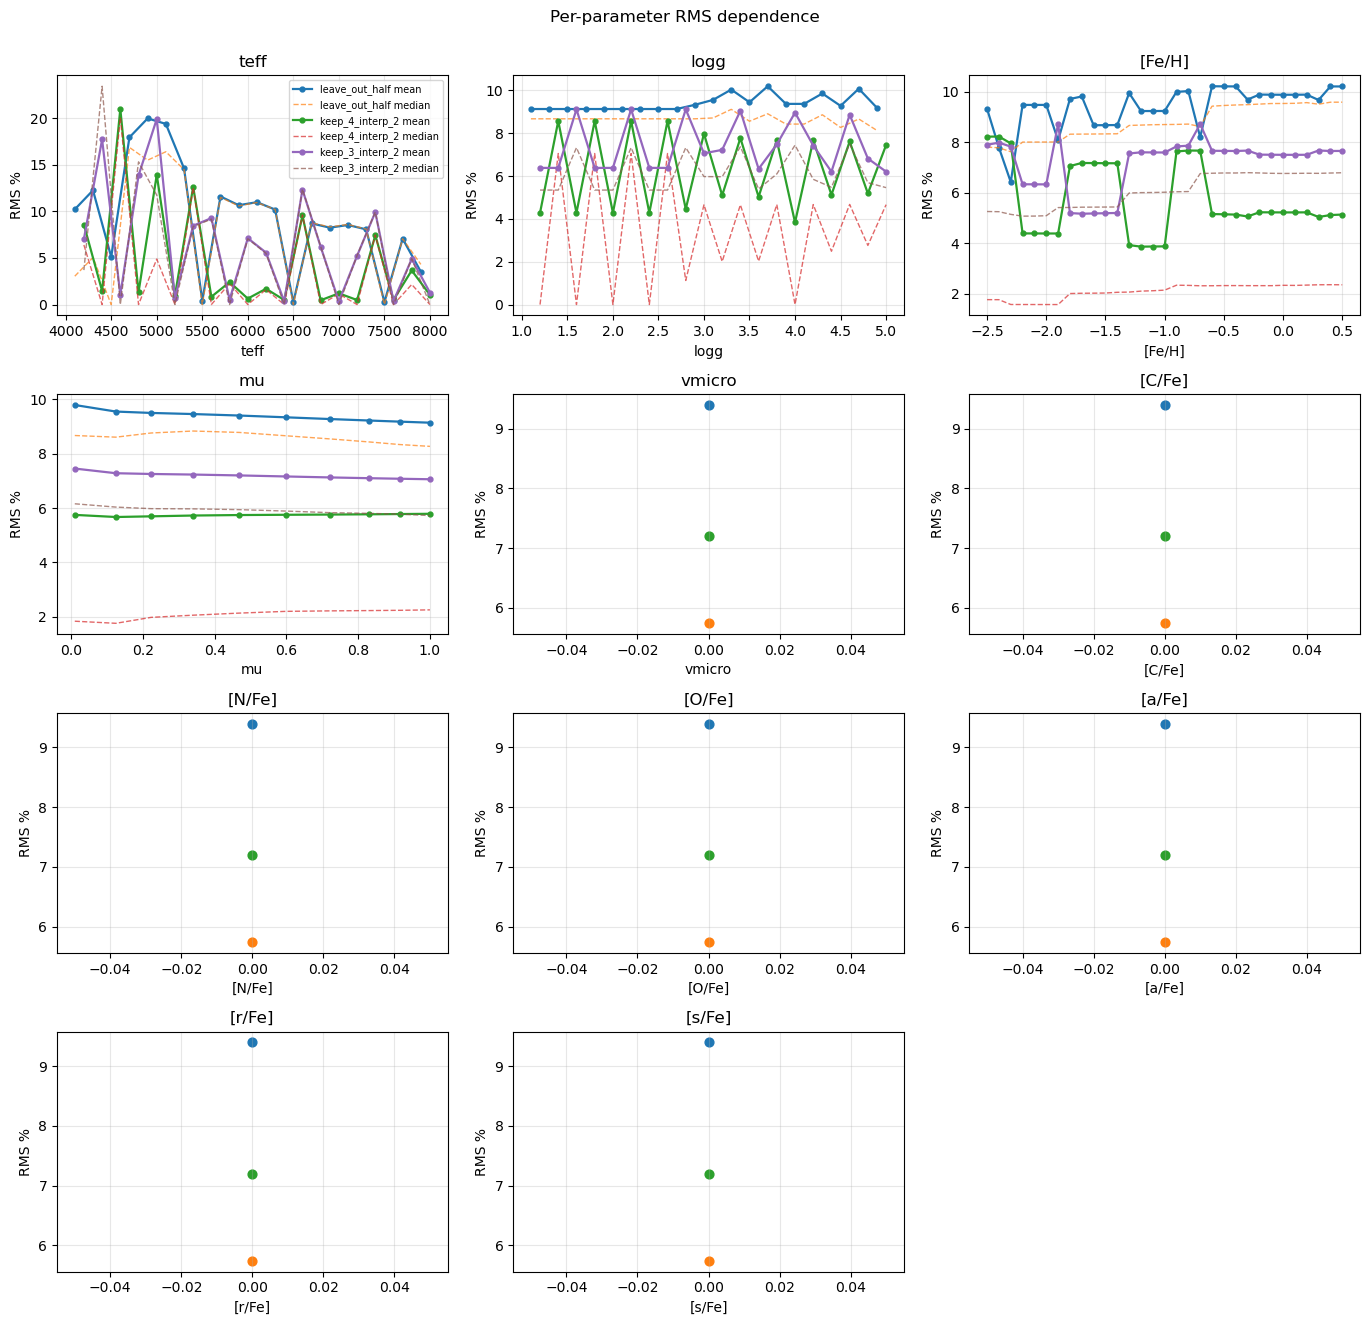

In [7]:
all_params = sorted({p for cfg in configs for p in by_param[cfg]["parameter"].unique()})
preferred = ["teff", "logg", "[Fe/H]", "mu", "vmicro"]
ordered = [p for p in preferred if p in all_params] + [
    p for p in all_params if p not in preferred
]

n_cols = 3
n_rows = (len(ordered) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4.6 * n_cols, 3.3 * n_rows), squeeze=False
)

for idx, pname in enumerate(ordered):
    ax = axes[idx // n_cols, idx % n_cols]
    plotted = False
    for cfg in configs:
        sub = by_param[cfg][by_param[cfg]["parameter"] == pname].sort_values("value")
        if sub.empty:
            continue
        if sub["value"].nunique() <= 1:
            ax.scatter(
                sub["value"], sub["rms_pct_mean"], s=40, label=f"{cfg} (mean)"
            )
        else:
            ax.plot(
                sub["value"],
                sub["rms_pct_mean"],
                "-o",
                ms=3.5,
                linewidth=1.6,
                label=f"{cfg} mean",
            )
            ax.plot(
                sub["value"],
                sub["rms_pct_median"],
                "--",
                linewidth=1.0,
                alpha=0.7,
                label=f"{cfg} median",
            )
        plotted = True

    ax.set_xlabel(pname)
    ax.set_ylabel("RMS %")
    ax.set_title(pname)
    ax.grid(alpha=0.3)
    if plotted and idx == 0:
        ax.legend(fontsize=7, loc="best")

for k in range(len(ordered), n_rows * n_cols):
    axes[k // n_cols, k % n_cols].set_visible(False)

fig.suptitle("Per-parameter RMS dependence", y=1.0)
fig.tight_layout()


## 6. Worst-reconstructed spectra

Top-N held-out spectra per config ranked by RMS %. Useful for spot-checking which corner of parameter space is breaking — usually low-Teff / high-metallicity / strong-feature regions.

In [8]:
TOP_N = 10

ignore_cols = {"row_idx"}
for cfg in configs:
    df = per_spec[cfg]
    cols = [
        c
        for c in df.columns
        if c not in ignore_cols and c not in {"rms_pct", "mean_pct", "max_abs_pct"}
    ]
    top = (
        df.sort_values("rms_pct", ascending=False)
        .head(TOP_N)
        .reset_index(drop=True)[cols + ["rms_pct", "mean_pct", "max_abs_pct"]]
    )
    print(f"\n=== {cfg}: top {TOP_N} by RMS % ===")
    with pd.option_context(
        "display.float_format", "{:,.3f}".format, "display.max_columns", None
    ):
        display(top)



=== leave_out_half: top 10 by RMS % ===


,teff,logg,[Fe/H],vmicro,[a/Fe],[C/Fe],[N/Fe],[O/Fe],[r/Fe],[s/Fe],mu,rms_pct,mean_pct,max_abs_pct
0,"5,100.000",2.500,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
1,"5,100.000",1.500,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
2,"5,100.000",2.700,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
3,"5,100.000",2.300,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
4,"5,100.000",2.100,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
5,"5,100.000",1.300,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
6,"5,100.000",1.100,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
7,"5,100.000",1.900,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
8,"5,100.000",1.700,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
9,"5,100.000",2.900,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.031,77.083,98.685



=== keep_4_interp_2: top 10 by RMS % ===


,teff,logg,[Fe/H],vmicro,[a/Fe],[C/Fe],[N/Fe],[O/Fe],[r/Fe],[s/Fe],mu,rms_pct,mean_pct,max_abs_pct
0,"5,000.000",1.200,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
1,"5,000.000",2.400,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
2,"5,000.000",1.600,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
3,"5,000.000",2.200,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
4,"5,000.000",1.400,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
5,"5,000.000",2.600,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
6,"5,000.000",2.000,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
7,"5,000.000",1.800,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.049,77.139,98.687
8,"5,000.000",2.800,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.031,77.083,98.685
9,"5,000.000",3.000,-2.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,78.029,77.248,99.360



=== keep_3_interp_2: top 10 by RMS % ===


,teff,logg,[Fe/H],vmicro,[a/Fe],[C/Fe],[N/Fe],[O/Fe],[r/Fe],[s/Fe],mu,rms_pct,mean_pct,max_abs_pct
0,"4,800.000",3.800,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,76.528,75.351,98.679
1,"4,800.000",3.400,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,76.261,75.315,98.844
2,"4,800.000",3.600,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,76.261,75.315,98.844
3,"4,800.000",4.000,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,75.963,74.880,98.674
4,"4,800.000",3.800,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.917,75.929,74.778,98.583
5,"4,800.000",3.200,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.125,75.901,75.585,98.057
6,"4,800.000",2.200,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.125,75.891,75.544,98.063
7,"4,800.000",2.600,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.125,75.891,75.544,98.063
8,"4,800.000",2.400,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.125,75.891,75.544,98.063
9,"4,800.000",2.000,-1.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.125,75.891,75.544,98.063


## 7. Example spectra: interpolation corners, held-out truth, reconstructed

The CSV summaries above do not store flux arrays. This section reloads the NLTE zarr
(same `--store-path` as the sweep), rebuilds the decimated grid for one preset, and
plots three held-out examples (**worst / median / best** RMS %).

- **Grey** — corner spectra on the decimated grid (opacity ∝ weight)
- **Orange dashed** — held-out truth (full catalogue)
- **Blue** — reconstructed (`get_weighted_batch` on decimated grid)

### Running on Gadi

1. **Clone / sync** the repo under scratch, e.g. `/scratch/y89/$USER/spice`.
2. **Start Jupyter from `benchmarks/`** (so imports resolve):
   ```bash
   cd /scratch/y89/$USER/spice/benchmarks
   module load python3/3.11.7   # or your conda env
   export JAX_PLATFORMS=cpu
   jupyter notebook --no-browser --port=8888
   ```
   On a compute node via PBS, request an interactive session with `storage=gdata/y89+scratch/y89`.
3. **Point `RESULTS_DIR`** (cell 1) at the sweep output, e.g.
   `/scratch/y89/$USER/spice/decimation_sweep` if you used `qsub -v OUT_DIR=...`.
4. The zarr store is found automatically at the Gadi path below; optionally:
   `export SPICE_SPECTRA_ZARR=/g/data/y89/.../regular_synthesized_spectra.zarr`

Building the decimated interpolator for one preset takes ~1–3 minutes on 8 CPUs.


In [ ]:
import os
import shutil
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")


def _find_sweep_dir() -> Path:
    """Locate benchmarks/ containing lazy_zarr_interpolation_decimation_sweep.py."""
    marker = "lazy_zarr_interpolation_decimation_sweep.py"
    candidates = [
        Path.cwd().resolve(),
        Path.cwd().resolve() / "benchmarks",
        Path(__file__).resolve().parent if "__file__" in dir() else None,
    ]
    user = os.environ.get("USER") or os.environ.get("LOGNAME") or ""
    if user:
        candidates += [
            Path(f"/scratch/y89/{user}/spice/benchmarks"),
            Path(f"/scratch/y89/{user}/spice"),
            Path.home() / "spice" / "benchmarks",
        ]
    for c in candidates:
        if c is None:
            continue
        if (c / marker).is_file():
            return c
        if (c / "benchmarks" / marker).is_file():
            return c / "benchmarks"
    return Path.cwd().resolve()


_sweep_dir = _find_sweep_dir()
if not (_sweep_dir / "lazy_zarr_interpolation_decimation_sweep.py").is_file():
    raise FileNotFoundError(
        f"Cannot find lazy_zarr_interpolation_decimation_sweep.py under {_sweep_dir}.\n"
        "On Gadi: cd /scratch/y89/$USER/spice/benchmarks (or your clone) before starting Jupyter."
    )
if str(_sweep_dir) not in sys.path:
    sys.path.insert(0, str(_sweep_dir))
for _p in (_sweep_dir, _sweep_dir.parent):
    _src = _p / "src"
    if (_src / "spice").is_dir() and str(_src) not in sys.path:
        sys.path.insert(0, str(_src))

import jax
import jax.numpy as jnp
import zarr

jax.config.update("jax_enable_x64", True)

from spice.spectrum.lazy_zarr_interpolator import LazyZarrInterpolator
from lazy_zarr_interpolation_decimation_sweep import (
    PRESETS,
    build_thermal_masks,
    load_catalogue,
    write_decimated_zarr,
)

# Paths (Gadi defaults). Override with environment variables if needed.
STORE_CANDIDATES = [
    Path(
        "/g/data/y89/mj8805/PAPER/regular_fe.zarr"
    ),
]
_env_store = os.environ.get("SPICE_SPECTRA_ZARR")
if _env_store:
    STORE_CANDIDATES.insert(0, Path(_env_store))

STORE_PATH = None
for c in STORE_CANDIDATES:
    if (c / "index.parquet").is_file():
        STORE_PATH = c.resolve()
        break

# Sweep CSV output (copy from PBS job OUT_DIR or symlink)
if "RESULTS_DIR" not in globals() or not Path(RESULTS_DIR).is_dir():
    _user = os.environ.get("USER") or ""
    _gadi_results = [
        Path(f"/scratch/y89/{_user}/spice/decimation_sweep"),
        Path(f"/scratch/y89/{_user}/spice/benchmarks/lazy_zarr_decimation_sweep"),
        _sweep_dir / "lazy_zarr_decimation_sweep",
        Path("../data/lazy_zarr_decimation_sweep"),
    ]
    for c in _gadi_results:
        if c.is_dir() and (c / "summary.csv").is_file():
            RESULTS_DIR = c.resolve()
            break

EXAMPLE_CONFIG = "leave_out_half"  # any preset in summary.csv

print("sweep dir:", _sweep_dir)
print("RESULTS_DIR:", RESULTS_DIR if "RESULTS_DIR" in globals() else "(set in cell 1)")
if STORE_PATH is None:
    print(
        "STORE_PATH not found — export SPICE_SPECTRA_ZARR=/path/to/regular_synthesized_spectra.zarr"
    )
else:
    print("Store:", STORE_PATH)
    print("Example preset:", EXAMPLE_CONFIG)


In [11]:
def build_decimated_interpolator(store_path: Path, config_name: str) -> tuple:
    """Return (interp_dec, flux_dec, z_full, wave, param_cols, df, tmp_dir)."""
    spec = PRESETS[config_name]
    df, param_cols = load_catalogue(store_path)

    st = summary.loc[summary["config"] == config_name].iloc[0]
    expected_rows = int(st["n_kept_rows"]) + int(st["n_held_rows_full_mask"])
    if abs(len(df) - expected_rows) > max(500, 0.01 * expected_rows):
        print(
            f"WARNING: index has {len(df)} rows but sweep metadata expects ~{expected_rows}.\n"
            f"  Use the same zarr store as the PBS job (--store-path)."
        )

    interp_full = LazyZarrInterpolator(
        str(store_path),
        params=param_cols,
        in_memory=False,
        sparse=True,
        accumulate_chunk_size=None,
    )
    cols = list(interp_full.grid_index.columns)
    teff_axis = np.asarray(interp_full.grid_index.axes[cols.index("teff")])
    logg_axis = np.asarray(interp_full.grid_index.axes[cols.index("logg")])
    teff_idx_all = np.searchsorted(teff_axis, df["teff"].to_numpy(dtype=np.float32))
    logg_idx_all = np.searchsorted(logg_axis, df["logg"].to_numpy(dtype=np.float32))

    keep_mask, _, _ = build_thermal_masks(
        teff_axis, logg_axis, teff_idx_all, logg_idx_all, spec
    )
    orig_kept_rowidx = df.loc[keep_mask, "row_idx"].to_numpy(dtype=int)
    flux_kept = np.asarray(interp_full.rowwise_data["flux"][orig_kept_rowidx])
    cont_kept = np.asarray(interp_full.rowwise_data["continuum"][orig_kept_rowidx])
    index_kept = df.loc[keep_mask, param_cols].copy()
    wave = np.asarray(interp_full.static_data["wavelength"])

    tmp_dir = Path(tempfile.mkdtemp(prefix=f"spice_nb_{config_name}_"))
    dec_path = tmp_dir / "decimated.zarr"
    write_decimated_zarr(dec_path, wave, flux_kept, cont_kept, index_kept, param_cols)
    interp_dec = LazyZarrInterpolator(
        str(dec_path),
        params=param_cols,
        in_memory=True,
        sparse=True,
        accumulate_chunk_size=8,
    )
    flux_dec = np.asarray(interp_dec.rowwise_data["flux"])
    z_full = zarr.open_group(str(store_path), mode="r")
    return interp_dec, flux_dec, z_full, wave, param_cols, df, tmp_dir


def catalogue_row_idx(df: pd.DataFrame, param_cols: list[str], row: pd.Series) -> int:
    """Map held-out parameters to flux row_idx in *this* store's index."""
    m = np.ones(len(df), dtype=bool)
    for c in param_cols:
        m &= np.isclose(
            df[c].to_numpy(dtype=np.float64),
            float(row[c]),
            rtol=0.0,
            atol=1e-5,
        )
    sub = df.loc[m]
    if len(sub) != 1:
        raise ValueError(
            f"expected 1 catalogue row, found {len(sub)} for "
            + ", ".join(f"{c}={float(row[c]):g}" for c in param_cols)
        )
    return int(sub["row_idx"].iloc[0])


def pick_example_indices(df: pd.DataFrame, rms_col: str = "rms_pct") -> dict[str, int]:
    order = np.argsort(df[rms_col].to_numpy())
    return {
        "best": int(order[0]),
        "median": int(order[len(order) // 2]),
        "worst": int(order[-1]),
    }


spectrum_examples: dict | None = None
_dec_tmp_dir = None

if STORE_PATH is not None and EXAMPLE_CONFIG in configs:
    held_df = per_spec[EXAMPLE_CONFIG].reset_index(drop=True)
    selections = pick_example_indices(held_df)
    print("Held-out examples (row in per_spectrum table):", selections)

    # Building the decimated interpolator loads kept rows from the full grid (~1-3 min).
    interp_dec, flux_dec, z_full, wave_np, param_cols, cat_df, _dec_tmp_dir = (
        build_decimated_interpolator(STORE_PATH, EXAMPLE_CONFIG)
    )
    param_cols_ex = [c for c in param_cols if c in held_df.columns]

    spectrum_examples = {
        "config": EXAMPLE_CONFIG,
        "selections": {},
    }
    for name, idx in selections.items():
        row = held_df.iloc[idx]
        query = row[param_cols_ex].to_numpy(dtype=np.float64)
        row_idx = catalogue_row_idx(cat_df, param_cols_ex, row)
        truth = np.asarray(z_full["flux"][row_idx], dtype=np.float64)
        pred = np.asarray(
            interp_dec.get_weighted_batch(jnp.asarray(query[None], dtype=jnp.float64))["flux"][0]
        )
        corner_rows, corner_weights = interp_dec.grid_index.lookup(
            jnp.asarray(query, dtype=jnp.float64)
        )
        corner_rows = np.asarray(corner_rows)
        corner_weights = np.asarray(corner_weights)
        spectrum_examples["selections"][name] = {
            "idx": idx,
            "row": row,
            "query": query,
            "truth": truth,
            "pred": pred,
            "corner_rows": corner_rows,
            "corner_weights": corner_weights,
            "rms_pct": float(row["rms_pct"]),
        }
    print(f"Built decimated interpolator for {EXAMPLE_CONFIG} ({len(flux_dec)} kept rows).")
elif STORE_PATH is None:
    pass
elif EXAMPLE_CONFIG not in configs:
    print(f"Config {EXAMPLE_CONFIG!r} not in sweep results; choose one of {configs}")


Held-out examples (row in per_spectrum table): {'best': 121376, 'median': 103993, 'worst': 36838}
  Use the same zarr store as the PBS job (--store-path).
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 2.0 s
Building sparse grid index...
Sparse grid index ready.


/scratch/y89/mj8805/spice/src/spice/spectrum/lazy_zarr_interpolator.py:584: UserWarning: Eager in_memory load requested for 2.41 GB of rowwise data, which exceeds the 2.15 GB threshold and may cause an out-of-memory crash. Consider in_memory='auto' or in_memory=False.
  warnings.warn(


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 2.5 s
Built decimated interpolator for leave_out_half (150381 kept rows).


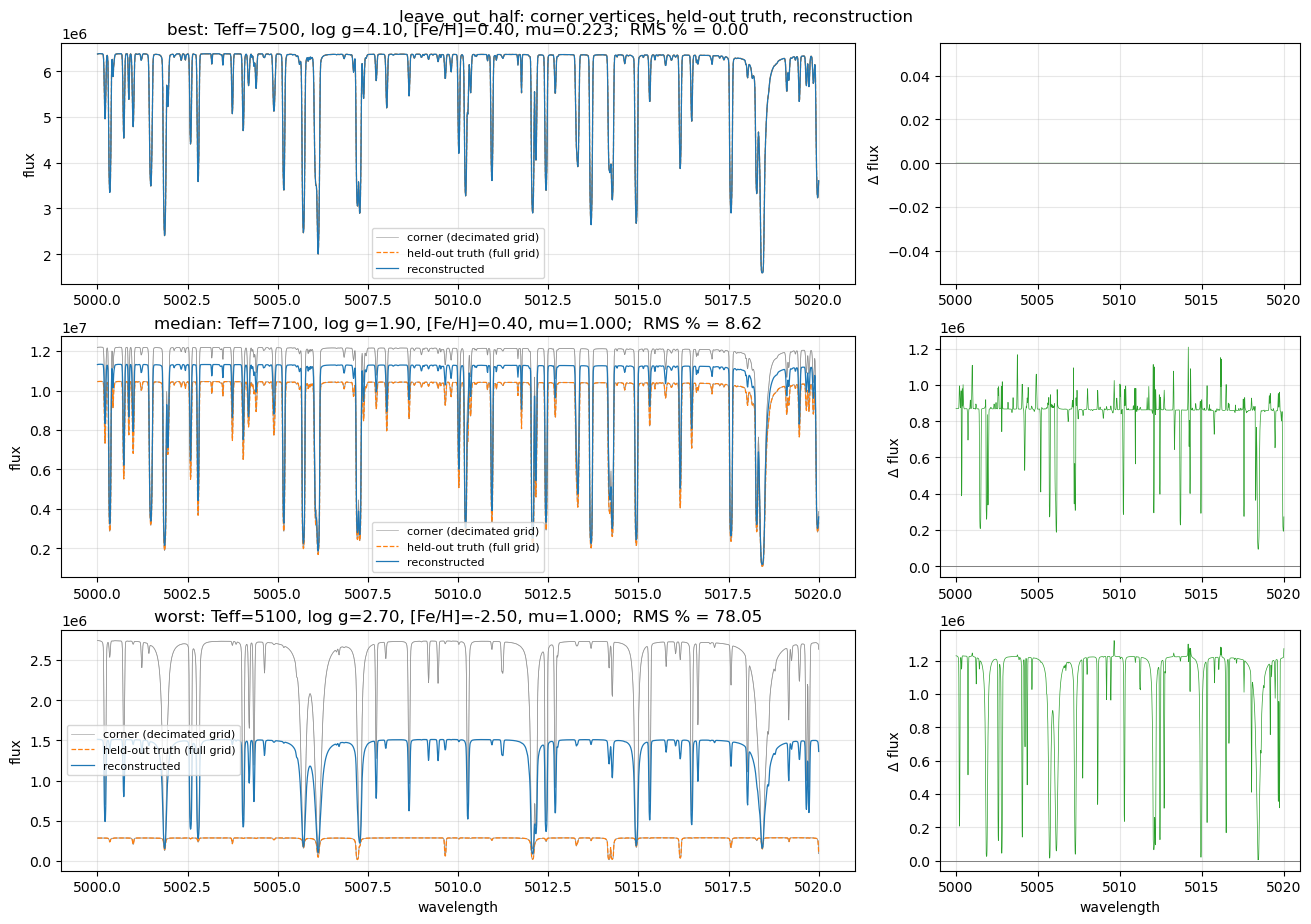

In [14]:
if spectrum_examples is not None:
    fig, axes = plt.subplots(
        3,
        2,
        figsize=(13, 9),
        gridspec_kw={"height_ratios": [1, 1, 1], "width_ratios": [2.2, 1]},
        constrained_layout=True,
    )
    for row_axes, (name, ex) in zip(axes, spectrum_examples["selections"].items()):
        ax_spec, ax_res = row_axes
        rm = ex["row"]
        rnp = ex["corner_rows"]
        wnp = ex["corner_weights"]
        contrib = (rnp >= 0) & (wnp > 1e-12)
        wmax = float(wnp[contrib].max()) if contrib.any() else 1.0
        for r, w in zip(rnp[contrib], wnp[contrib]):
            ax_spec.plot(
                wave_np,
                flux_dec[int(r)],
                lw=0.5,
                color="0.55",
                alpha=min(0.22 + 0.55 * (w / wmax), 0.9),
                label="corner (decimated grid)" if r == rnp[contrib][0] else None,
            )
        ax_spec.plot(
            wave_np,
            ex["truth"],
            lw=0.9,
            ls="--",
            color="C1",
            label="held-out truth (full grid)",
            zorder=5,
        )
        ax_spec.plot(
            wave_np,
            ex["pred"],
            lw=0.9,
            color="C0",
            label="reconstructed",
            zorder=5,
        )
        ax_spec.set_ylabel("flux")
        ax_spec.set_title(
            f"{name}: Teff={float(rm['teff']):.0f}, log g={float(rm['logg']):.2f}, "
            f"[Fe/H]={float(rm['[Fe/H]']):.2f}, mu={float(rm['mu']):.3f};  "
            f"RMS % = {ex['rms_pct']:.2f}"
        )
        ax_spec.legend(loc="best", fontsize=8)
        ax_spec.grid(alpha=0.3)

        ax_res.plot(wave_np, ex["pred"] - ex["truth"], lw=0.5, color="C2")
        ax_res.axhline(0.0, color="gray", lw=0.7)
        ax_res.set_ylabel("Δ flux")
        ax_res.grid(alpha=0.3)

    axes[-1, 0].set_xlabel("wavelength")
    axes[-1, 1].set_xlabel("wavelength")
    fig.suptitle(
        f"{spectrum_examples['config']}: corner vertices, held-out truth, reconstruction",
        y=1.01,
    )
    plt.show()
else:
    print("Skipping spectrum overlay (no store or examples).")


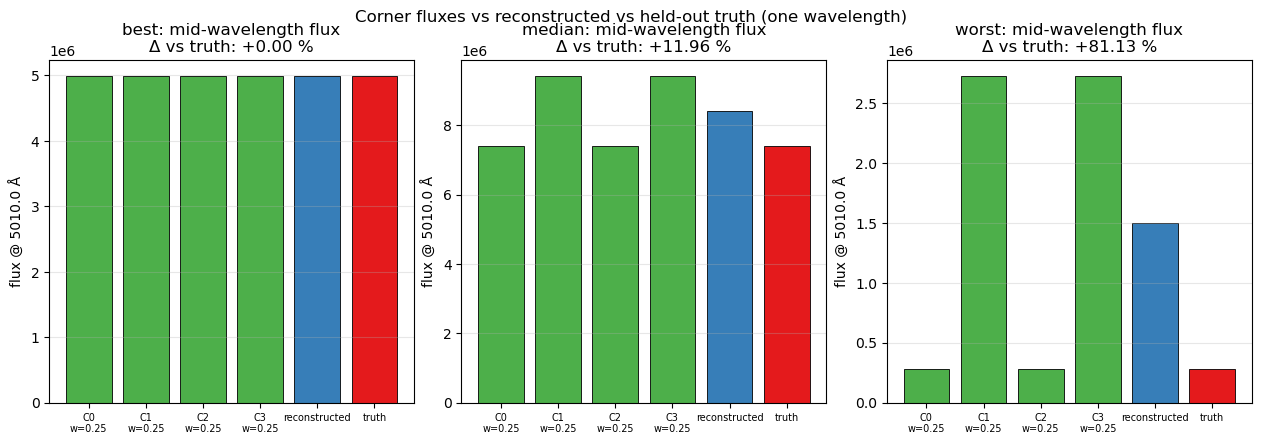

In [15]:
if spectrum_examples is not None:
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), constrained_layout=True)
    for ax, (name, ex) in zip(axes, spectrum_examples["selections"].items()):
        rm = ex["row"]
        rnp = ex["corner_rows"]
        wnp = ex["corner_weights"]
        contrib = (rnp >= 0) & (wnp > 1e-12)
        items = sorted(
            zip(rnp[contrib], wnp[contrib]), key=lambda x: -float(x[1])
        )
        labels, vals, colors = [], [], []
        nshow = min(len(items), 10)
        for k, (r, w) in enumerate(items[:nshow]):
            labels.append(f"C{k}\nw={w:.2f}")
            vals.append(float(flux_dec[int(r), len(flux_dec[0]) // 2]))
            colors.append("#4daf4a")
        fi = float(ex["pred"][len(ex["pred"]) // 2])
        ft = float(ex["truth"][len(ex["truth"]) // 2])
        labels += ["reconstructed", "truth"]
        vals += [fi, ft]
        colors += ["#377eb8", "#e41a1c"]
        x = np.arange(len(vals))
        ax.bar(x, vals, color=colors, edgecolor="k", linewidth=0.6)
        ax.set_xticks(x, labels, fontsize=7)
        ax.set_ylabel(f"flux @ {wave_np[len(wave_np)//2]:.1f} Å")
        den = max(abs(fi), abs(ft), 1e-30)
        ax.set_title(
            f"{name}: mid-wavelength flux\n"
            f"Δ vs truth: {100 * (fi - ft) / den:+.2f} %"
        )
        ax.grid(axis="y", alpha=0.3)
        if len(items) > nshow:
            ax.text(
                0.02,
                0.95,
                f"+{len(items) - nshow} more corners",
                transform=ax.transAxes,
                va="top",
                fontsize=7,
            )
    fig.suptitle("Corner fluxes vs reconstructed vs held-out truth (one wavelength)", y=1.02)
    plt.show()


In [16]:
if _dec_tmp_dir is not None:
    shutil.rmtree(_dec_tmp_dir, ignore_errors=True)
    print("Removed temporary decimated zarr:", _dec_tmp_dir)


Removed temporary decimated zarr: /jobfs/168683016.gadi-pbs/spice_nb_leave_out_half_9l6q5jlx


## 8. Original sweep figures

PNGs written by `plot_case` / `plot_summary_comparison` inside `lazy_zarr_interpolation_decimation_sweep.py`. They are embedded here so the notebook is a one-stop report when sharing the sweep.

leave_out_half_errors.png


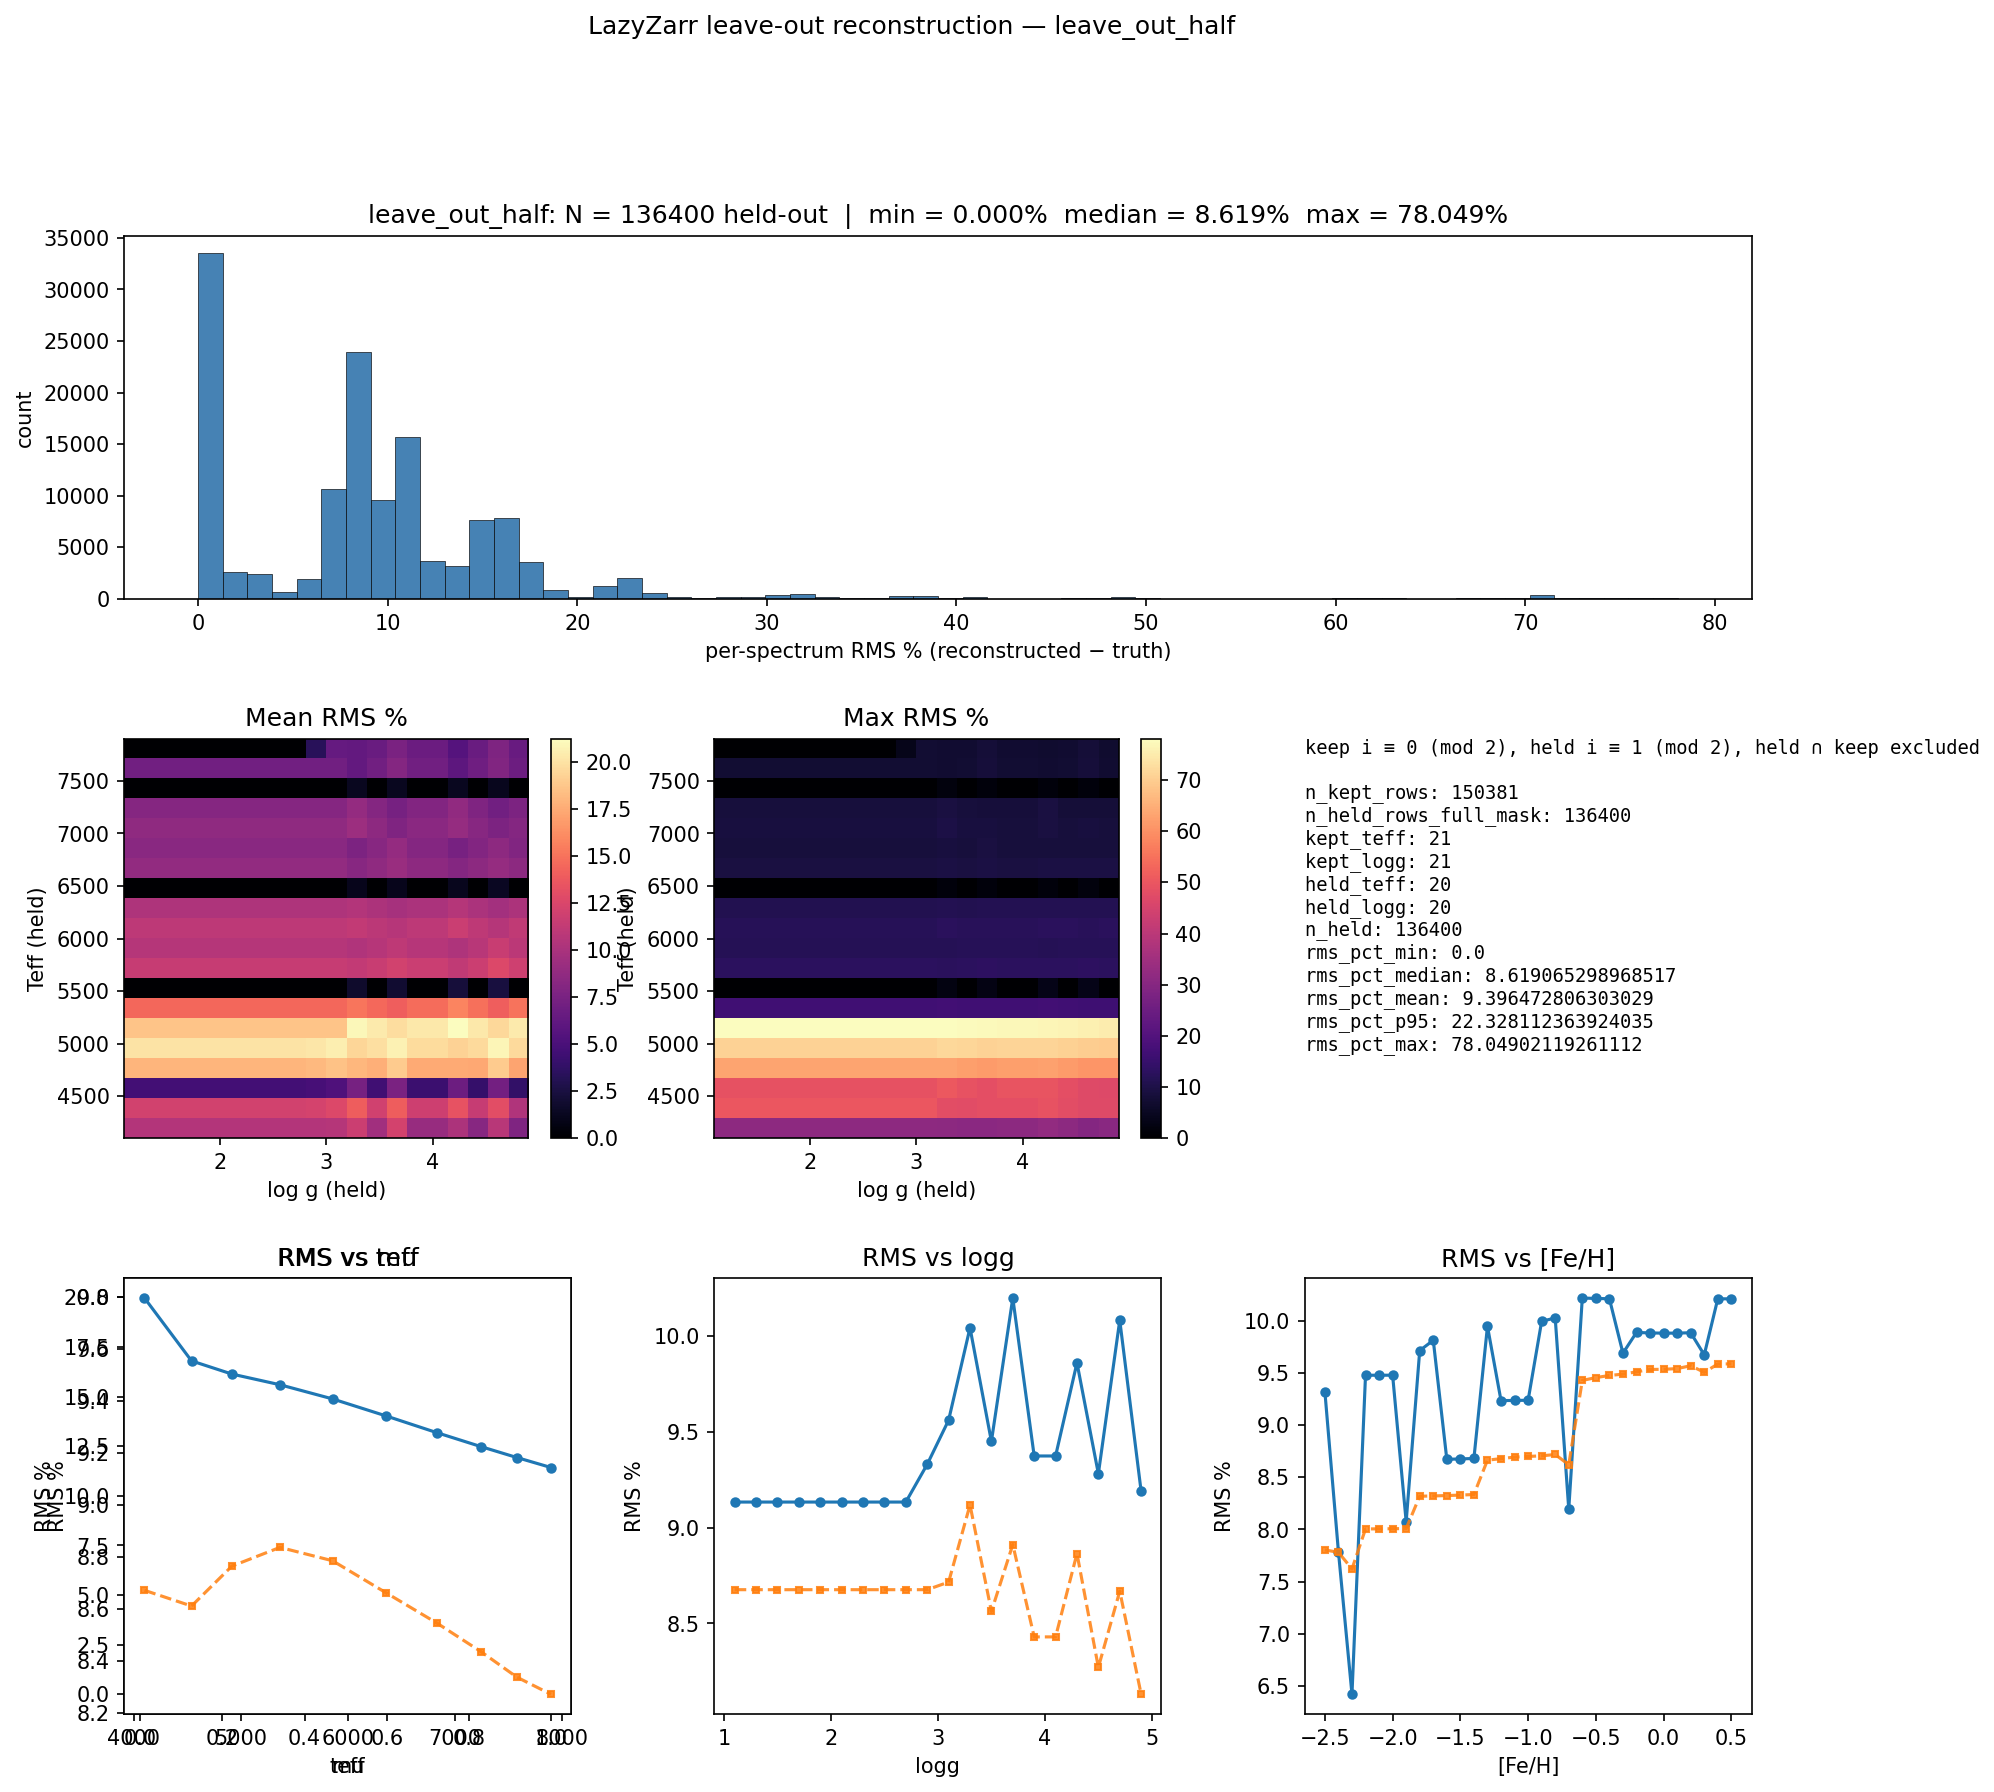

keep_4_interp_2_errors.png


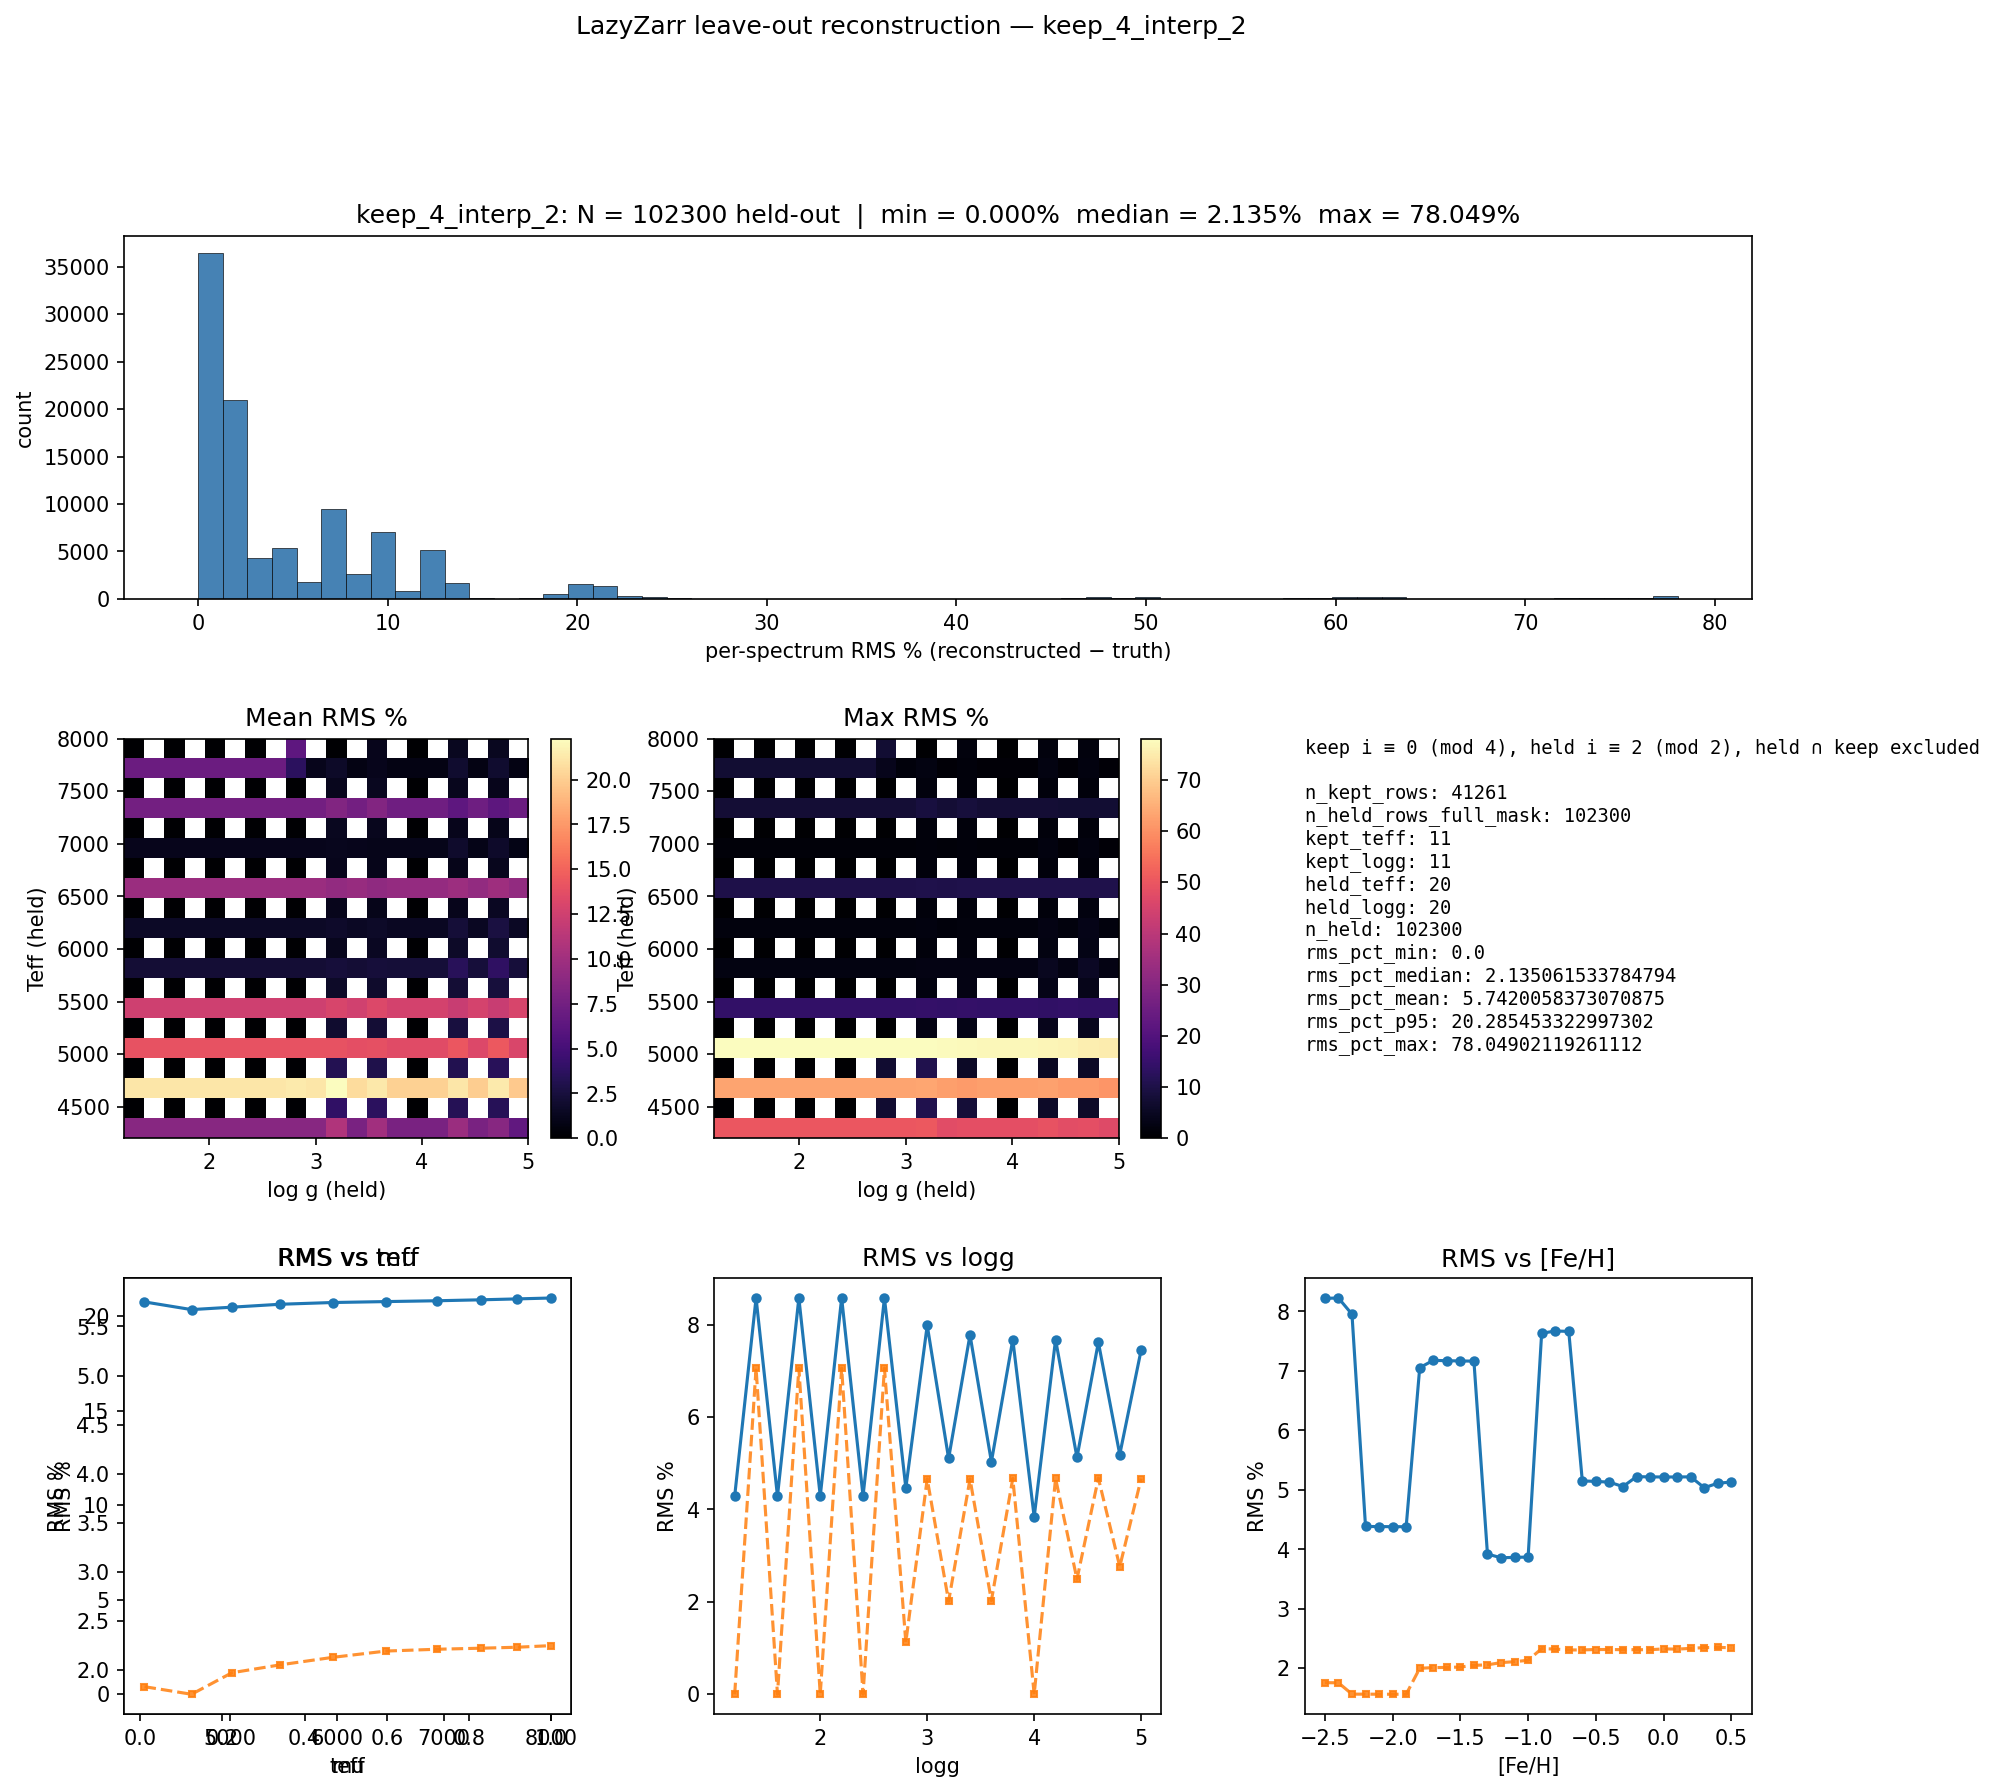

keep_3_interp_2_errors.png


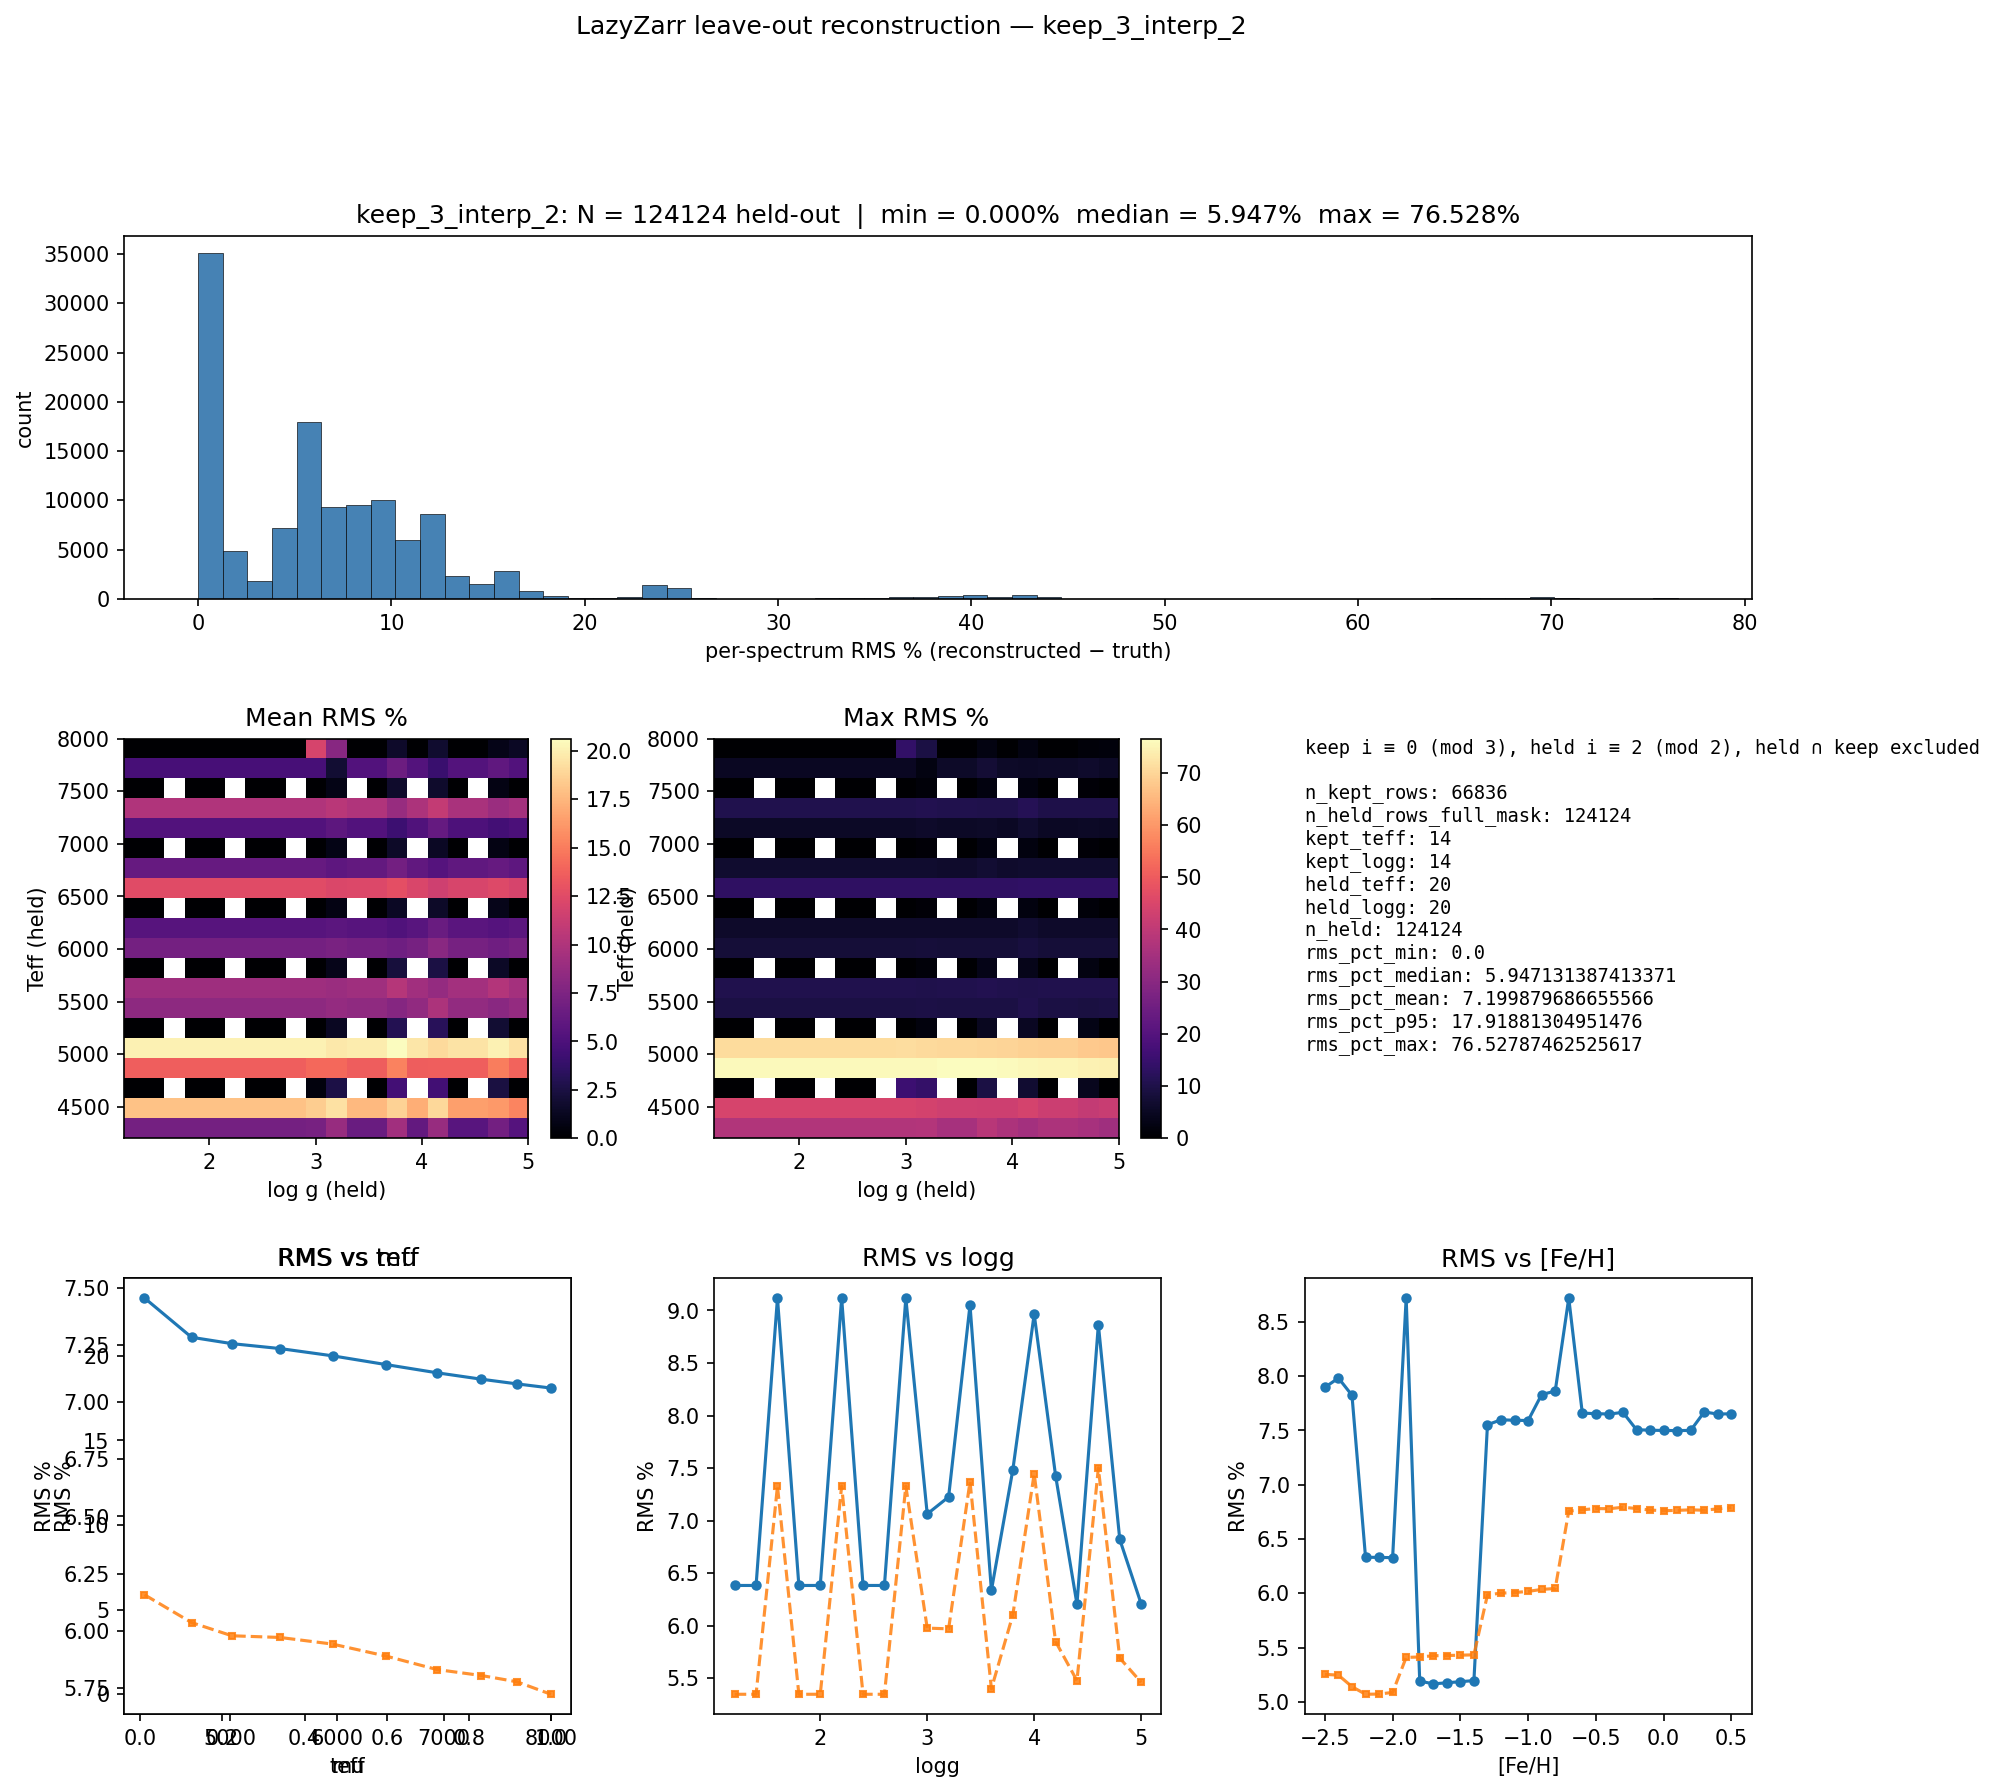

summary_comparison.png


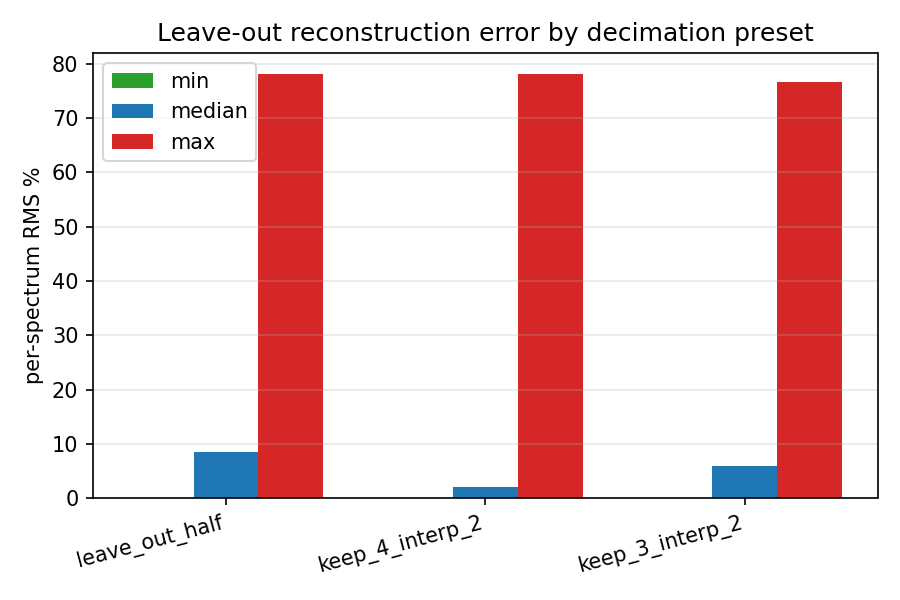

In [17]:
for cfg in configs:
    png = RESULTS_DIR / f"{cfg}_errors.png"
    if png.is_file():
        print(png.name)
        display(Image(filename=str(png)))

cmp_png = RESULTS_DIR / "summary_comparison.png"
if cmp_png.is_file():
    print(cmp_png.name)
    display(Image(filename=str(cmp_png)))
